# N-BEATS mit M4

In dieser Übung arbeitest du mit stündlichen Zeitreihen aus dem M4-Datensatz und vergleichst klassische Forecasting-Methoden mit N-BEATS.

Du wählst zunächst eine Serie aus, trainierst anschließend drei Referenzmodelle und analysierst deren Vorhersagen:
- SARIMA als klassische Baseline
- ein generisches N-BEATS
- ein interpretierbares N-BEATS

Zum Schluss konfigurierst du selbst ein weiteres N-BEATS-Modell mit dem Ziel, die Referenzmodelle zu übertreffen.

Hinweise:
- Die M4-Zeitreihen sind anonymisiert; fachliche Interpretation ist daher nur eingeschränkt möglich.
- Der Fokus liegt auf Modellverhalten, Hyperparametern und Forecast-Qualität.

Weiterführende Quellen:
- M4-Datensatz: https://github.com/Mcompetitions/M4-methods/tree/master/Dataset
- M4 Competition Paper: https://www.sciencedirect.com/science/article/pii/S0169207019301128
- N-BEATS Paper: https://arxiv.org/abs/1905.10437

## Bibliotheken laden

Die folgenden Pakete werden für Datenaufbereitung, Visualisierung und das Training der N-BEATS-Modelle verwendet.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from nbeats_pytorch.model import NBeatsNet
import torch
import torch.optim as optim
from IPython.display import display
import contextlib
import io
import re

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.12.1+cu126 | Device: cpu


## Daten laden

Hier werden die Trainings- und Testdaten der stündlichen M4-Zeitreihen eingelesen und in ein handlicheres Format überführt.

In [2]:

DATA_DIR = Path("data")
LOOKBACK = 24 * 7
SEASON_LENGTH = 24

def load_m4_split():
    train_df = pd.read_csv(DATA_DIR / "Hourly-train.csv")
    test_df = pd.read_csv(DATA_DIR / "Hourly-test.csv")
    train_df = train_df.rename(columns={"V1": "series_id"})
    test_df = test_df.rename(columns={"V1": "series_id"})
    return train_df, test_df


def row_to_series(row: pd.Series) -> pd.Series:
    values = pd.to_numeric(row.iloc[1:], errors="coerce").dropna().astype("float32")
    return pd.Series(values.to_numpy(), index=np.arange(1, len(values) + 1), name=row["series_id"])


preview_train, _ = load_m4_split()
print("Hourly-Serien:", len(preview_train))

Hourly-Serien: 50


<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Wähle eine Serie aus und lass den nachfolgenden Codeblock laufen</span>
</div>

## Serie auswählen

Wähle eine der verfügbaren Zeitreihen aus. Die Diagramme zeigen dir den vollständigen Verlauf sowie einen Zoom auf den Bereich rund um den Train/Test-Split.

Achte beim Auswählen auf Muster wie Trend, Saisonalität, Niveauwechsel oder Ausreißer.

In [3]:
def build_selection(index_1based: int) -> dict:
    train_df, test_df = load_m4_split()
    idx = index_1based - 1

    train_series = row_to_series(train_df.iloc[idx])
    test_series = row_to_series(test_df.iloc[idx])
    full_values = np.concatenate([train_series.values, test_series.values])
    full_series = pd.Series(full_values, index=np.arange(1, len(full_values) + 1), name=train_series.name)

    return {
        "series_id": str(train_series.name),
        "train": train_series,
        "test": test_series,
        "full": full_series,
        "test_x": np.arange(len(train_series) + 1, len(full_series) + 1),
    }

selection_state = {}
train_df, _ = load_m4_split()
series_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=len(train_df),
    step=1,
    description="Serie",
    continuous_update=False,
    layout=widgets.Layout(width="80%"),
)
plot_output = widgets.Output()


def get_current_selection():
    return build_selection(series_slider.value)


def redraw(*_):
    selection = get_current_selection()
    full = selection["full"]
    train = selection["train"]
    test = selection["test"]
    test_x = selection["test_x"]
    split = len(train)
    horizon = len(test)
    zoom = min(len(full), max(6 * horizon, LOOKBACK))
    tail = full.iloc[-zoom:]

    with plot_output:
        plot_output.clear_output(wait=True)
        print(f"Aktive Serie: {selection['series_id']}")
        print(f"Trainingslänge: {len(train)} | Testhorizont: {horizon}")
        print()

        fig, axes = plt.subplots(2, 1, figsize=(14, 7))

        axes[0].plot(full.index, full.values, color="steelblue", linewidth=1.0)
        axes[0].axvline(split + 0.5, color="crimson", linestyle="--", label="Train/Test-Split")
        axes[0].set_title(f"Hourly | {selection['series_id']} | Train={len(train)} | Test={horizon}")
        axes[0].set_ylabel("Wert")
        axes[0].grid(alpha=0.3)
        axes[0].legend()

        axes[1].plot(tail.index, tail.values, color="steelblue", linewidth=1.1, label="Gesamtverlauf")
        axes[1].plot(test_x, test.values, color="black", linewidth=2.0, label="Offizieller Test")
        axes[1].axvline(split + 0.5, color="crimson", linestyle="--", label="Split")
        axes[1].set_title("Zoom auf den letzten Abschnitt")
        axes[1].set_xlabel("Zeitindex")
        axes[1].set_ylabel("Wert")
        axes[1].grid(alpha=0.3)
        axes[1].legend()

        fig.tight_layout()
        display(fig)
        plt.close(fig)


selection_state.update(get_current_selection())
series_slider.observe(redraw, names="value")
redraw()

display(widgets.VBox([series_slider, plot_output]))

### Auswahl übernehmen

Mit der nächsten Zelle wird die aktuell gewählte Serie als Arbeitsgrundlage für alle folgenden Modelle fest übernommen.

In [4]:
if "series_slider" in globals():
    selection = build_selection(series_slider.value)
    selection_state.clear()
    selection_state.update(selection)
elif selection_state:
    selection = dict(selection_state)
else:
    raise ValueError("Bitte zuerst in Schritt 2 eine Serie auswählen.")

series_id = selection["series_id"]
y_train = selection["train"].astype("float32")
y_test = selection["test"].astype("float32")
y_full = selection["full"].astype("float32")
HORIZON = len(y_test)
test_x = selection["test_x"]

print(f"Ausgewählte Serie: {series_id} | Trainingslänge: {len(y_train)} | Testhorizont: {HORIZON}")

Ausgewählte Serie: H365 | Trainingslänge: 960 | Testhorizont: 48


## Baseline: SARIMA

Zum Einstieg trainierst du ein klassisches SARIMA-Modell. Es dient als Referenz, an der du die N-BEATS-Varianten später messen kannst.

In [5]:
# Das Model metrics DataFrame wird erstellt, um die Ergebnisse der verschiedenen Modelle zu speichern.
model_metrics = pd.DataFrame({
    "Modell": pd.Series(dtype="string"),
    "RMSE": pd.Series(dtype="float64"),
    "MAPE [%]": pd.Series(dtype="float64"),
})

### Hilfsfunktionen für Auswertung

Die folgenden Funktionen berechnen Fehlermetriken und visualisieren Forecasts sowie Residuen. Du musst den Code nicht im Detail nachvollziehen.

In [6]:
# Der Code ist nicht wirklich relevant für euch

def score_forecast(
    model_name: str,
    y_true: pd.Series,
    y_pred,
    y_train_context: pd.Series,
    forecast_index=None,
    history_points: int = 168,
    color: str = "#e45756",
):
    forecast_index = np.asarray(forecast_index)
    y_pred_values = y_pred.to_numpy(dtype="float32")

    y_true_plot = pd.Series(y_true.to_numpy(dtype="float32"), index=forecast_index, name="Ist")
    y_pred_series = pd.Series(y_pred_values, index=forecast_index, name=model_name)
    residuals = pd.Series(
        y_true_plot.values - y_pred_series.values,
        index=forecast_index,
        name=f"Residuen {model_name}",
    )


    history_points = max(0, int(history_points))

    history_start = max(0, len(y_train_context) - history_points)
    history_values = y_train_context.iloc[history_start:]
    history_x = history_values.index.to_numpy()

    _, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    if len(history_values) > 0:
        axes[0].plot(history_x, history_values.values, color="lightgray", linewidth=1.5, label="Trainingskontext")
        axes[0].axvline(history_x[-1] + 0.5, color="crimson", linestyle="--", alpha=0.8, label="Forecast-Start")

    axes[0].plot(y_true_plot.index, y_true_plot.values, color="black", linewidth=2.0, label="Ist")
    axes[0].plot(y_pred_series.index, y_pred_series.values, color=color, linewidth=2.0, label=f"Prognose: {model_name}")
    axes[0].set_title(f"Forecast vs. Ist | {model_name}")
    axes[0].set_xlabel("Zeitindex")
    axes[0].set_ylabel("Wert")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1.0)
    axes[1].scatter(residuals.index, residuals.values, color=color, s=24, alpha=0.9)
    axes[1].set_title(f"Residuen | {model_name}")
    axes[1].set_xlabel("Zeitindex")
    axes[1].set_ylabel("Residuum")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    metrics = {
        "Modell": model_name,
        "RMSE": root_mean_squared_error(y_true_plot.values, y_pred_series.values),
        "MAPE [%]": mean_absolute_percentage_error(y_true_plot.values, y_pred_series.values) * 100,
    }
    
    return {
        "metrics": metrics,
        "forecast": y_pred_series,
        "residuals": residuals,
    }


print(f"Aktive Serie für das Scoring: {series_id} (Hourly)")

Aktive Serie für das Scoring: H365 (Hourly)


### SARIMA trainieren

Führe das Training aus und betrachte anschließend Forecast, Residuen und Kennzahlen. Diese Ergebnisse bilden die erste Vergleichsbasis.

c:\Users\saita\Repos\AI-for-Business-Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\saita\Repos\AI-for-Business-Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\saita\Repos\AI-for-Business-Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\saita\Repos\AI-for-Business-Prognosis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: F

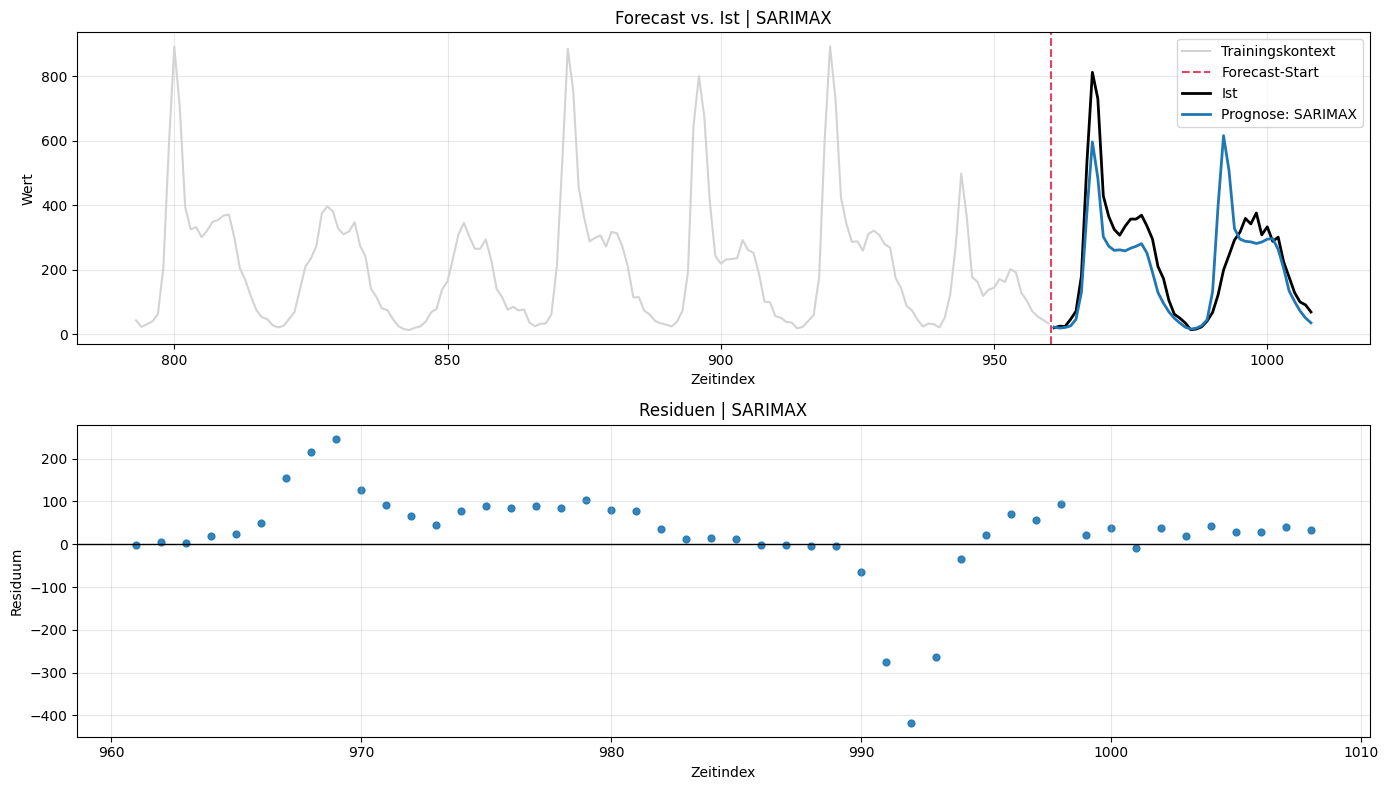

,Modell,RMSE,MAPE [%]
0,SARIMAX,109.69,34.93


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEASONAL_PERIOD = 24
SARIMA_ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, SEASONAL_PERIOD)

SARIMA_NAME = "SARIMAX"

sarima_model = SARIMAX(
    y_train,
    order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,
    )
sarima_model = sarima_model.fit(disp=False)
sarima_forecast = sarima_model.get_forecast(steps=HORIZON).predicted_mean
sarima_forecast = pd.Series(
    sarima_forecast.to_numpy(dtype="float32"),
    index=test_x,
    name=SARIMA_NAME,
    )

sarimax_result = score_forecast(
    model_name=SARIMA_NAME,
    y_true=y_test,
    y_pred=sarima_forecast,
    y_train_context=y_train,
    forecast_index=test_x,
    color="#1f77b4",
    )

model_metrics = pd.concat([model_metrics, pd.DataFrame([sarimax_result["metrics"]])], ignore_index=True)
model_metrics = model_metrics.round(2)

display(model_metrics)

<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Analysiere die Graphen und beantworte die Reflektionsfragen</span>
</div>

**Reflexion**

Beurteile die Vorhersage des SARIMA-Modells:
- Welche Muster werden gut getroffen?
- Wo weicht das Modell deutlich vom Testverlauf ab?
- Wirken die Residuen eher zufällig oder zeigen sie noch Struktur?

## Generic N-BEATS

Nun trainierst du ein generisches N-BEATS-Modell. Diese Variante nutzt ausschließlich generische Blöcke und lernt die Struktur der Zeitreihe direkt aus den Daten.

Das Modell besteht aus mehreren Stacks und Blöcken, die gemeinsam die Vorhersage aufbauen. Im weiteren Verlauf helfen dir die Visualisierungen dabei zu erkennen, welche Beiträge einzelne Modellteile liefern.

### Hilfsfunktionen für N-BEATS

Die folgenden Funktionen bereiten Trainingsfenster vor und visualisieren die Beiträge einzelner Stacks und Blöcke. Für die Übung reicht es, die erzeugten Plots zu interpretieren.

In [8]:
# NBEATS hilfsfunktionen, nicht relevant für euch
def plot_nbeats_outputs(model, test_index, series_id):
    block_series = {
        output["layer"]: pd.Series(output["value"][0], index=test_index, name=output["layer"])
        for output in model._intermediary_outputs
    }
    stack_series = aggregate_nbeats_contributions(block_series, level="stack")
    stack_colors = ["#4c78a8", "#f58518", "#54a24b", "#e45756"]
    plot_nbeats_stack_grid(
        stack_series,
        block_series,
        f"N-BEATS | {series_id} (Hourly)",
        stack_colors,
    )


def plot_fit_history(log_text: str, name: str):
    train_losses = []
    val_losses = []
    for line in log_text.splitlines():
        match = re.search(r"loss:\s*([0-9.]+).*val_loss:\s*([0-9.]+)", line)
        if match:
            train_losses.append(float(match.group(1)))
            val_losses.append(float(match.group(2)))

    epochs = np.arange(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_losses, color="#4c78a8", linewidth=2.0, label="Training loss")
    plt.plot(epochs, val_losses, color="#e45756", linewidth=2.0, label="Validation loss")
    plt.title(f"{name} | Training vs. Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def aggregate_nbeats_contributions(component_series: dict, level: str = "stack") -> dict:
    aggregated = {}
    for layer_name, series in component_series.items():
        key = layer_name if level == "block" else layer_name.split("-")[0]
        aggregated[key] = aggregated.get(key, pd.Series(0.0, index=series.index, name=key)) + series.astype("float32")
    return dict(sorted(aggregated.items()))


def plot_nbeats_stack_grid(stack_series: dict, block_series: dict, title: str, stack_colors: list[str]):
    stack_items = list(stack_series.items())
    block_groups = {}
    for layer_name, series in sorted(block_series.items()):
        stack_name = layer_name.split("-")[0]
        block_groups.setdefault(stack_name, []).append((layer_name, series))

    rows = 1 + max(len(group) for group in block_groups.values())
    cols = len(stack_items)
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.2 * rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for col, (stack_name, stack_values) in enumerate(stack_items):
        color = stack_colors[col % len(stack_colors)]
        axes[0, col].plot(stack_values.index, stack_values.astype("float32").values, color=color, linewidth=2.4)
        axes[0, col].set_title(f"Stack {stack_name}")
        axes[0, col].grid(alpha=0.3)

        blocks = block_groups.get(stack_name, [])
        for row in range(1, rows):
            if row - 1 < len(blocks):
                block_name, block_values = blocks[row - 1]
                axes[row, col].plot(block_values.index, block_values.astype("float32").values, color=color, linewidth=2.0)
                axes[row, col].set_title(block_name)
                axes[row, col].grid(alpha=0.3)
            else:
                axes[row, col].axis("off")

    for row in range(rows):
        for col in range(cols):
            if row == rows - 1:
                axes[row, col].set_xlabel("Zeitindex")

    axes[0, 0].set_ylabel("Stack")
    for row in range(1, rows):
        axes[row, 0].set_ylabel("Block")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [9]:
# Vorbereitung der Trainings- und Testfenster für das N-BEATS-Modell

def prepare_nbeats_windows(y_train: pd.Series, horizon: int, val_windows: int = 1):
    backcast_length = 2 * 7 * 24
    values = y_train.values.astype("float32")
    X, Y = [], []
    for start in range(len(values) - backcast_length - horizon + 1):
        X.append(values[start:start + backcast_length])
        Y.append(values[start + backcast_length:start + backcast_length + horizon])

    if len(X) <= val_windows:
        raise ValueError(
            f"Nicht genug Fenster fuer eine getrennte Validierung: windows={len(X)}, val_windows={val_windows}"
        )

    X = np.asarray(X, dtype="float32")[..., None]
    Y = np.asarray(Y, dtype="float32")[..., None]

    x_train_windows = X[:-val_windows]
    y_train_windows = Y[:-val_windows]
    x_val_windows = X[-val_windows:]
    y_val_windows = Y[-val_windows:]

    print(
        "using backcast_length:",
        backcast_length,
        "| horizon:",
        horizon,
        "| train windows:",
        len(x_train_windows),
        "| validation windows:",
        len(x_val_windows),
    )

    return (
        backcast_length,
        x_train_windows,
        y_train_windows,
        x_val_windows,
        y_val_windows,
        values[-backcast_length:].reshape(1, backcast_length, 1),
    )

### Generic N-BEATS trainieren

Trainiere das Modell und vergleiche anschließend Lernkurven, Forecast und Stack-/Block-Beiträge mit der SARIMA-Baseline.

using backcast_length: 336 | horizon: 48 | train windows: 576 | validation windows: 1
| N-Beats
| --  Stack Generic (#0) (share_weights_in_stack=True)
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463601857920
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463601857920
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463601857920
| --  Stack Generic (#1) (share_weights_in_stack=True)
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463591604992
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463591604992
     | -- GenericBlock(units=128, thetas_dim=6, backcast_length=336, forecast_length=48, share_thetas=False) at @2463591604992
| --  Stack Generic (#2) (share_

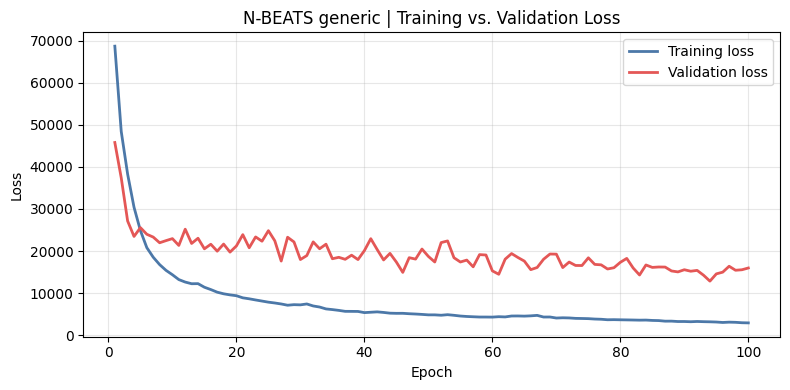

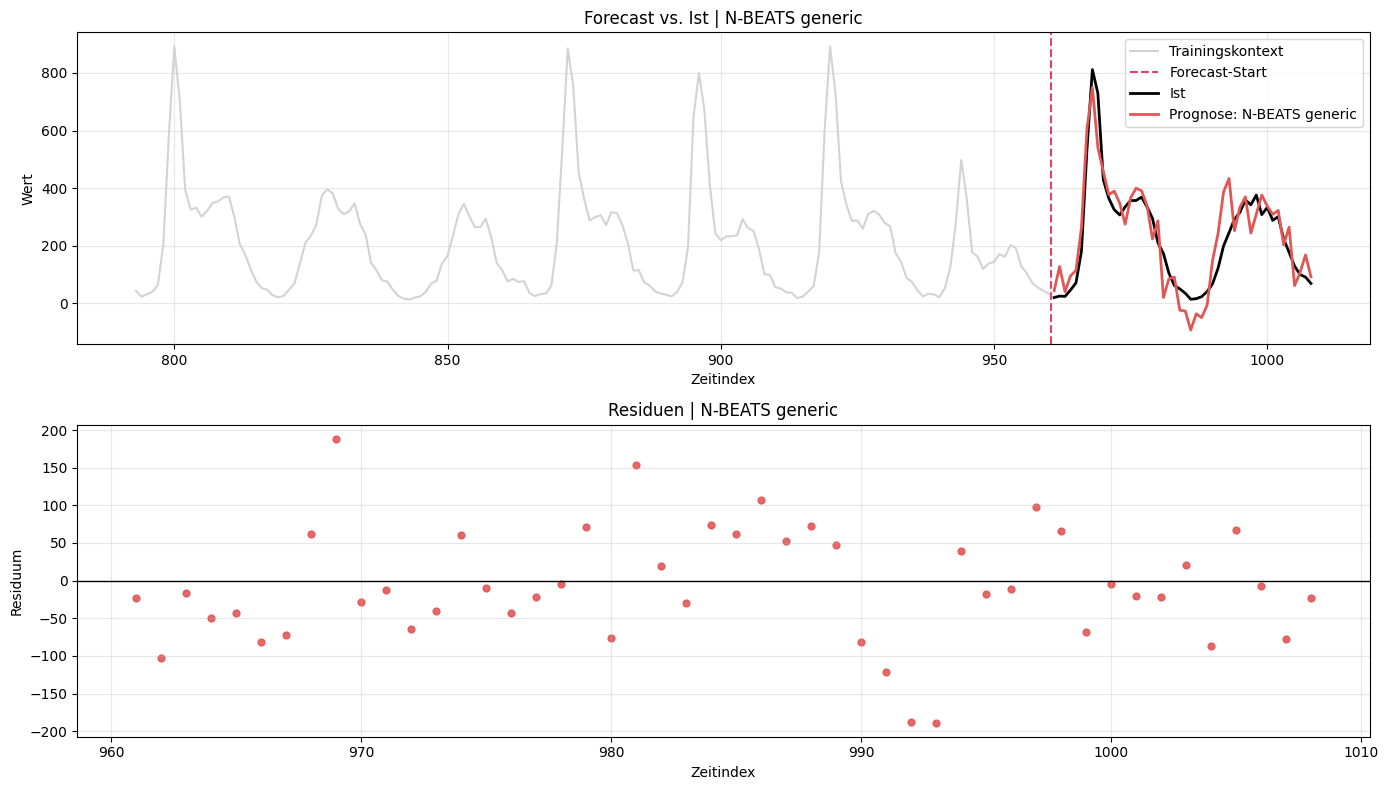

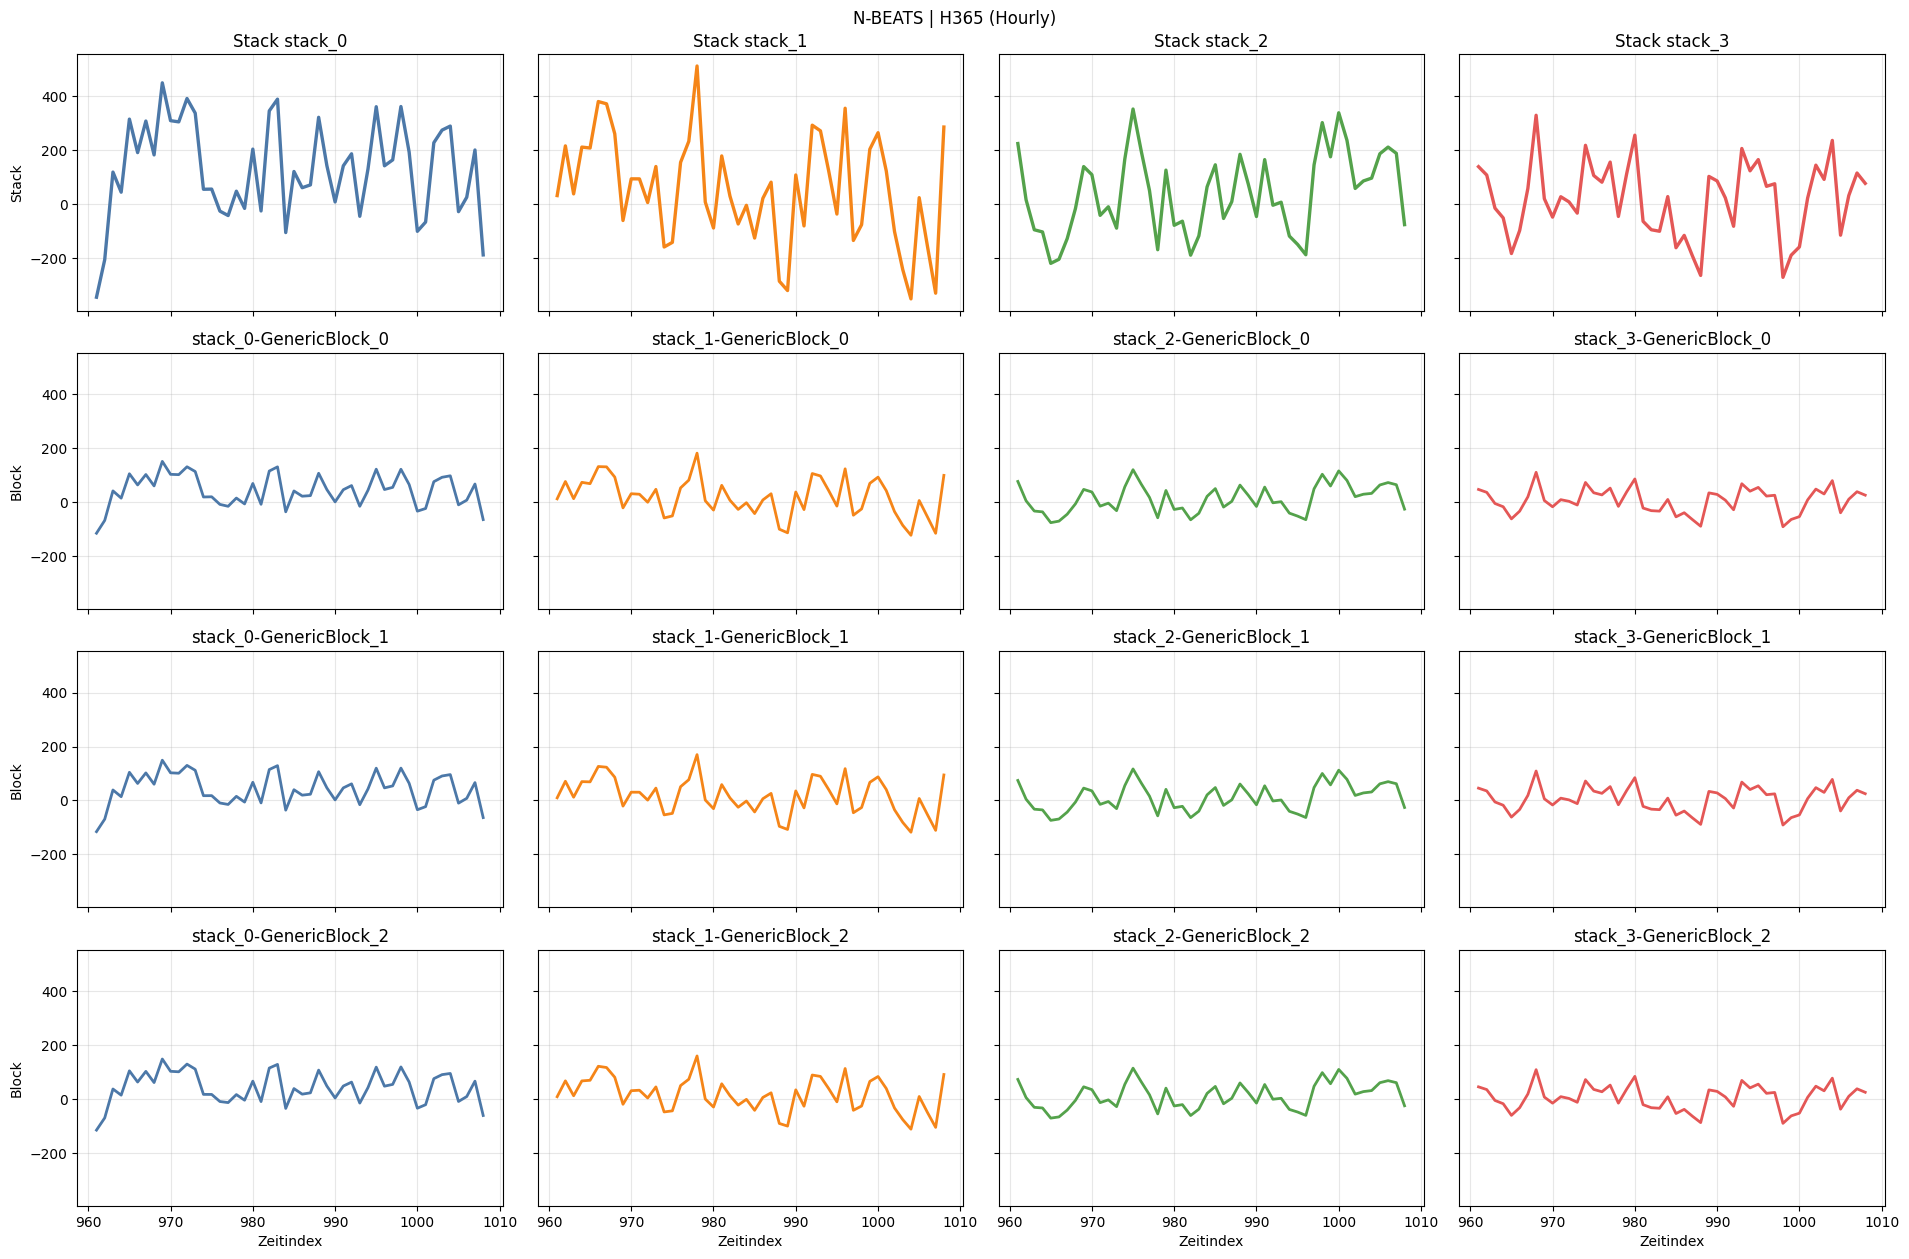

,Modell,RMSE,MAPE [%]
0,SARIMAX,109.69,34.93
1,N-BEATS generic,76.23,77.85


In [10]:
backcast_length, x_train_model, y_train_model, x_val, y_val, x_forecast = prepare_nbeats_windows(y_train, HORIZON)

generic_nbeats_name = "N-BEATS generic"

nbeats_model = NBeatsNet(
    device=device,
    stack_types=(NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK),
    nb_blocks_per_stack=3,
    forecast_length=HORIZON,
    backcast_length=backcast_length,
    thetas_dim=(6,6,6,6),            # also increment if you increase number of stacks
    share_weights_in_stack=True,
    hidden_layer_units=128,
    nb_harmonics=None,
    )
nbeats_optimizer = optim.Adam(nbeats_model.parameters(), lr=1e-3, weight_decay=1e-5)
nbeats_model.compile(loss="mse", optimizer=nbeats_optimizer)

loss_log = io.StringIO()
with contextlib.redirect_stdout(loss_log):
    nbeats_model.fit(
        x_train_model,
        y_train_model,
        validation_data=(x_val, y_val),
        epochs=100,
        batch_size=64,
    )
plot_fit_history(loss_log.getvalue(), generic_nbeats_name)

nbeats_model.enable_intermediate_outputs()
nbeats_forecast = pd.Series(
    nbeats_model.predict(x_forecast).reshape(-1),
    index=test_x,
    name=generic_nbeats_name,
)

nbeats_result = score_forecast(
    model_name=generic_nbeats_name,
    y_true=y_test,
    y_pred=nbeats_forecast,
    y_train_context=y_train,
    forecast_index=test_x,
    color="#e15756",
    )

model_metrics = pd.concat([model_metrics, pd.DataFrame([nbeats_result["metrics"]])], ignore_index=True)
model_metrics = model_metrics.round(2)

plot_nbeats_outputs(nbeats_model, test_x, series_id)

display(model_metrics)

<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Analysiere die Graphen und beantworte die Reflektionsfragen</span>
</div>

**Reflexion**

Vergleiche Generic N-BEATS mit SARIMA:
- Ist die Vorhersage näher am Testverlauf?
- Welche Unterschiede fallen im Fehlerbild auf?
- Erkennst du wiederkehrende Muster in den Beiträgen der Stacks oder Blöcke?

## Interpretable N-BEATS

Als Nächstes trainierst du eine interpretierbare Variante von N-BEATS. Hier werden unterschiedliche Blocktypen verwendet, um zum Beispiel Trend- und saisonale Anteile gezielter abzubilden.

### Interpretable N-BEATS trainieren

Führe das Training aus und achte besonders darauf, ob die Modellbeiträge leichter interpretierbar sind als bei der generischen Variante.

| N-Beats
| --  Stack Trend (#0) (share_weights_in_stack=True)
     | -- TrendBlock(units=64, thetas_dim=4, backcast_length=336, forecast_length=48, share_thetas=True) at @2464072001984
     | -- TrendBlock(units=64, thetas_dim=4, backcast_length=336, forecast_length=48, share_thetas=True) at @2464072001984
| --  Stack Seasonality (#1) (share_weights_in_stack=True)
     | -- SeasonalityBlock(units=64, thetas_dim=48, backcast_length=336, forecast_length=48, share_thetas=True) at @2463593722416
     | -- SeasonalityBlock(units=64, thetas_dim=48, backcast_length=336, forecast_length=48, share_thetas=True) at @2463593722416
| --  Stack Generic (#2) (share_weights_in_stack=True)
     | -- GenericBlock(units=64, thetas_dim=4, backcast_length=336, forecast_length=48, share_thetas=False) at @2464066570816
     | -- GenericBlock(units=64, thetas_dim=4, backcast_length=336, forecast_length=48, share_thetas=False) at @2464066570816


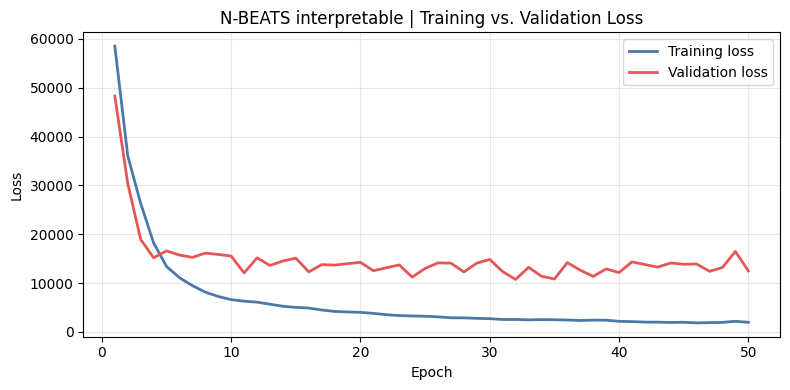

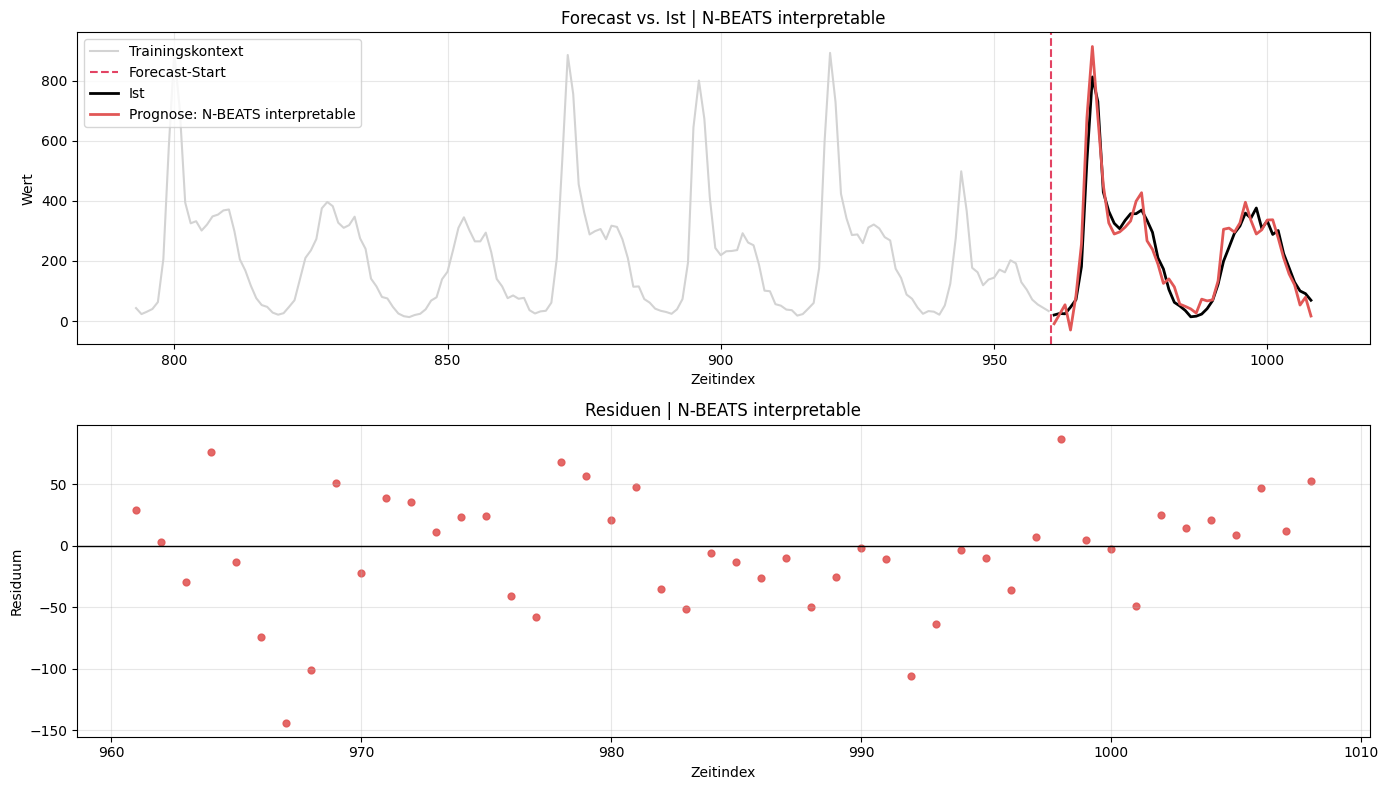

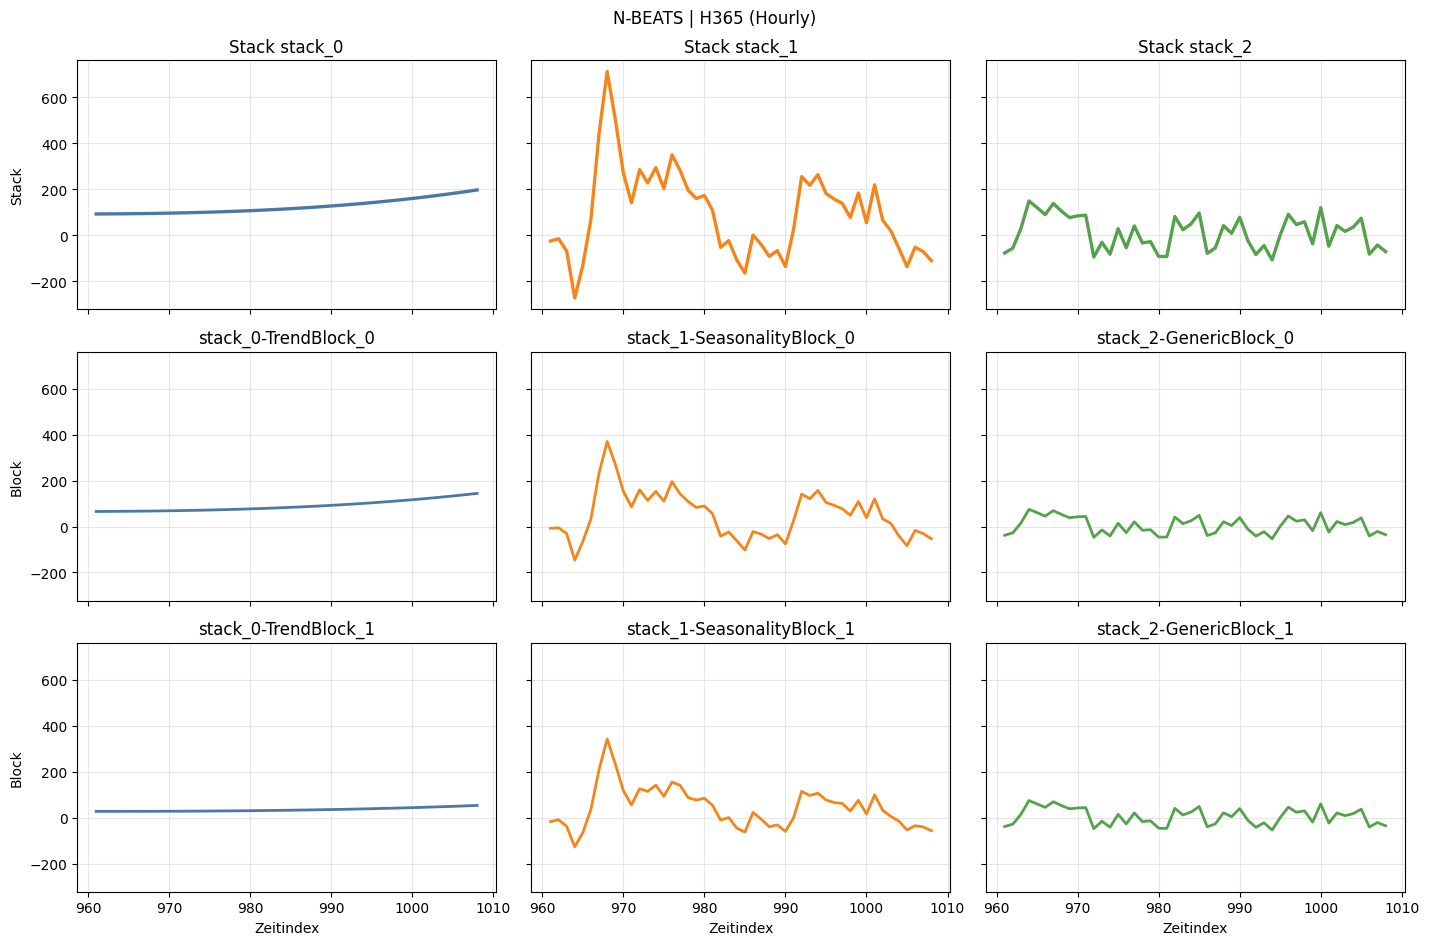

,Modell,RMSE,MAPE [%]
0,SARIMAX,109.69,34.93
1,N-BEATS generic,76.23,77.85
2,N-BEATS interpretable,47.48,35.82


In [11]:
interpretable_nbeats_name = "N-BEATS interpretable"

interpretable_nbeats = NBeatsNet(
    device=device,
    stack_types=(NBeatsNet.TREND_BLOCK, NBeatsNet.SEASONALITY_BLOCK, NBeatsNet.GENERIC_BLOCK),
    nb_blocks_per_stack=2,
    forecast_length=HORIZON,
    backcast_length=backcast_length,
    thetas_dim=(4, 4, 4),            # also increment if you increase number of stacks
    share_weights_in_stack=True,
    hidden_layer_units=64,
    nb_harmonics=None,
    )
interpretable_nbeats_optimizer = optim.Adam(interpretable_nbeats.parameters(), lr=1e-3, weight_decay=1e-5)
interpretable_nbeats.compile(loss="mse", optimizer=interpretable_nbeats_optimizer)

loss_log = io.StringIO()
with contextlib.redirect_stdout(loss_log):
    interpretable_nbeats.fit(
        x_train_model,
        y_train_model,
        validation_data=(x_val, y_val),
        epochs=50,
        batch_size=64,
    )
plot_fit_history(loss_log.getvalue(), interpretable_nbeats_name)

interpretable_nbeats.enable_intermediate_outputs()
interpretable_forecast = pd.Series(
    interpretable_nbeats.predict(x_forecast).reshape(-1),
    index=test_x,
    name=interpretable_nbeats_name,
)

nbeats_result = score_forecast(
    model_name=interpretable_nbeats_name,
    y_true=y_test,
    y_pred=interpretable_forecast,
    y_train_context=y_train,
    forecast_index=test_x,
    color="#e15756",
    )

if interpretable_nbeats_name not in model_metrics["Modell"].values:
    model_metrics = pd.concat([model_metrics, pd.DataFrame([nbeats_result["metrics"]])], ignore_index=True)
model_metrics = model_metrics.round(2)

plot_nbeats_outputs(interpretable_nbeats, test_x, series_id)

display(model_metrics)

<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Analysiere die Graphen und beantworte die Reflektionsfragen</span>
</div>

**Reflexion**

Vergleiche das interpretierbare Modell mit Generic N-BEATS:
- Welche Variante liefert die bessere Vorhersage?
- Lassen sich Trend, Saisonalität oder Restkomponenten in den Beiträgen plausibel erkennen?
- Welche Modellstruktur wirkt für diese Serie geeigneter?

## Custom N-BEATS

Jetzt bist du an der Reihe: Konfiguriere ein eigenes N-BEATS-Modell und versuche, die bisherigen Varianten zu schlagen.

Verändere gezielt nur wenige Parameter gleichzeitig, damit du ihren Einfluss nachvollziehen kannst.

<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Wähle Parameter und schlage die bisherigen Modellvarianten</span>
</div>

### Wichtige Stellschrauben

Für dein eigenes Modell sind vor allem diese Parameter relevant:
- `stack_types`: Art und Reihenfolge der verwendeten Blöcke
  - Optionen: `NBeatsNet.TREND_BLOCK`, `NBeatsNet.SEASONALITY_BLOCK`, `NBeatsNet.GENERIC_BLOCK`
- `nb_blocks_per_stack`: Anzahl der Blöcke pro Stack
- `thetas_dim`: Anzahl der Koeffizienten, die ein Block intern lernt, um seine Vorhersage aufzubauen
- `hidden_layer_units`: Größe der versteckten Schichten

Optional kannst du auch mit Optimierungsparametern experimentieren:
- `learning rate`: Bestimmt, wie stark die Gewichte pro Optimierungsschritt angepasst werden.
- `weight decay`: Fügt Regularisierung hinzu und kann Overfitting reduzieren.
- `epochs`: Legt fest, wie oft das Modell die Trainingsdaten vollständig durchläuft.


### Referenzkonfigurationen

Die folgenden beiden Konfigurationen kannst du als Ausgangspunkt verwenden. 

**Generic N-BEATS**

```python
nbeats_model = NBeatsNet(
    device=device,
    stack_types=(NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK),
    nb_blocks_per_stack=3,
    forecast_length=HORIZON,
    backcast_length=backcast_length,
    thetas_dim=(6,6,6,6),            # also increment if you increase number of stacks
    share_weights_in_stack=True,
    hidden_layer_units=128,
    nb_harmonics=None,
    )
nbeats_optimizer = optim.Adam(nbeats_model.parameters(), lr=1e-3, weight_decay=1e-5)
nbeats_model.compile(loss="mse", optimizer=nbeats_optimizer)
```

**Interpretable N-BEATS**

```python
interpretable_nbeats = NBeatsNet(
    device=device,
    stack_types=(NBeatsNet.TREND_BLOCK, NBeatsNet.SEASONALITY_BLOCK, NBeatsNet.GENERIC_BLOCK),
    nb_blocks_per_stack=2,
    forecast_length=HORIZON,
    backcast_length=backcast_length,
    thetas_dim=(4, 4, 4),            # also increment if you increase number of stacks
    share_weights_in_stack=True,
    hidden_layer_units=64,
    nb_harmonics=None,
    )
interpretable_nbeats_optimizer = optim.Adam(interpretable_nbeats.parameters(), lr=1e-3, weight_decay=1e-5)
interpretable_nbeats.compile(loss="mse", optimizer=interpretable_nbeats_optimizer)
```

In [ ]:
custom_nbeats_name = "N-BEATS custom"

custom_nbeats = NBeatsNet(
    device=device,
    stack_types=(TODO),
    nb_blocks_per_stack=TODO,
    forecast_length=HORIZON,
    backcast_length=backcast_length,
    thetas_dim=(TODO, TODO, TODO),            # also increment if you increase number of stacks
    share_weights_in_stack=True,
    hidden_layer_units=TODO,
    nb_harmonics=None,
    )
nbeats_optimizer = optim.Adam(custom_nbeats.parameters(), lr=1e-3, weight_decay=1e-5)
custom_nbeats.compile(loss="mse", optimizer=nbeats_optimizer)

loss_log = io.StringIO()
with contextlib.redirect_stdout(loss_log):
    custom_nbeats.fit(
        x_train_model,
        y_train_model,
        validation_data=(x_val, y_val),
        epochs=120,
        batch_size=64,
        )
plot_fit_history(loss_log.getvalue(), custom_nbeats_name)

custom_nbeats.enable_intermediate_outputs()
custom_forecast = pd.Series(
    custom_nbeats.predict(x_forecast).reshape(-1),
    index=test_x,
    name=custom_nbeats_name,
)

nbeats_result = score_forecast(
    model_name=custom_nbeats_name,
    y_true=y_test,
    y_pred=custom_forecast,
    y_train_context=y_train,
    forecast_index=test_x,
    color="#e15756",
    )

model_metrics = pd.concat([model_metrics, pd.DataFrame([nbeats_result["metrics"]])], ignore_index=True)
model_metrics = model_metrics.round(2)

plot_nbeats_outputs(custom_nbeats, test_x, series_id)

display(model_metrics)

SyntaxError: invalid syntax (2089629243.py, line 5)

## Vergleich der Modelle

Vergleiche zum Schluss die Fehlermetriken aller Modelle sowie die visuellen Unterschiede ihrer Forecasts. Entscheidend ist nicht nur der kleinste Fehlerwert, sondern auch, wie plausibel und stabil die Vorhersage wirkt.

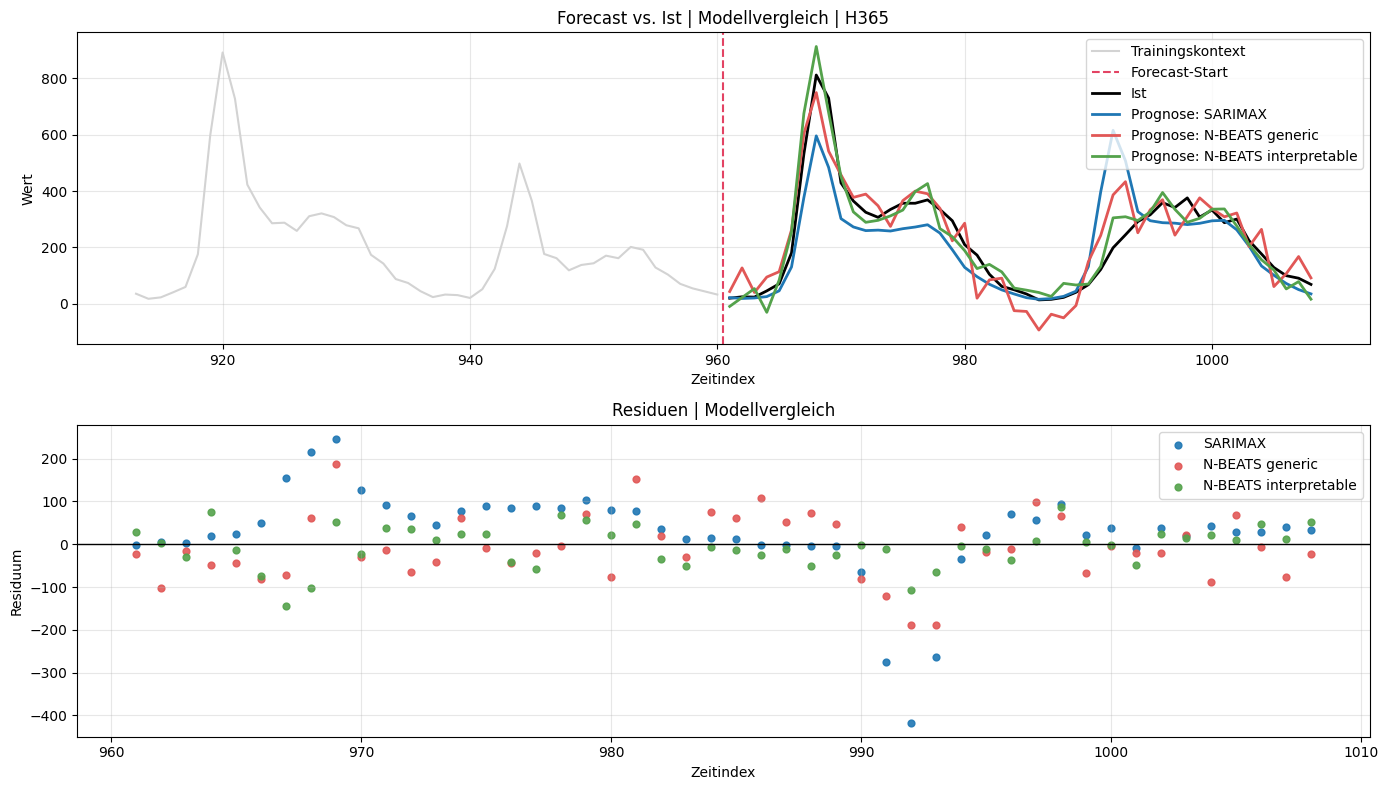

In [13]:
forecast_index = np.asarray(test_x)
y_true_plot = pd.Series(y_test.to_numpy(dtype="float32"), index=forecast_index, name="Ist")
sarima_plot = pd.Series(sarima_forecast.to_numpy(dtype="float32"), index=forecast_index, name="SARIMAX")
generic_plot = pd.Series(nbeats_forecast.to_numpy(dtype="float32"), index=forecast_index, name="N-BEATS generic")
interpretable_plot = pd.Series(interpretable_forecast.to_numpy(dtype="float32"), index=forecast_index, name="N-BEATS interpretable")
has_custom_plot = "custom_forecast" in globals()
if has_custom_plot:
    custom_plot = pd.Series(custom_forecast.to_numpy(dtype="float32"), index=forecast_index, name="N-BEATS custom")

history_points = 24 * 2
history_start = max(0, len(y_train) - history_points)
history_values = y_train.iloc[history_start:]
history_x = history_values.index.to_numpy()

sarima_residuals = pd.Series(y_true_plot.values - sarima_plot.values, index=forecast_index, name="Residuen SARIMAX")
generic_residuals = pd.Series(y_true_plot.values - generic_plot.values, index=forecast_index, name="Residuen N-BEATS generic")
interpretable_residuals = pd.Series(y_true_plot.values - interpretable_plot.values, index=forecast_index, name="Residuen N-BEATS interpretable")
if has_custom_plot:
    custom_residuals = pd.Series(y_true_plot.values - custom_plot.values, index=forecast_index, name="Residuen N-BEATS custom")

_, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

if len(history_values) > 0:
    axes[0].plot(history_x, history_values.values, color="lightgray", linewidth=1.5, label="Trainingskontext")
    axes[0].axvline(history_x[-1] + 0.5, color="crimson", linestyle="--", alpha=0.8, label="Forecast-Start")

axes[0].plot(y_true_plot.index, y_true_plot.values, color="black", linewidth=2.0, label="Ist")
axes[0].plot(sarima_plot.index, sarima_plot.values, color="#1f77b4", linewidth=2.0, label="Prognose: SARIMAX")
axes[0].plot(generic_plot.index, generic_plot.values, color="#e15756", linewidth=2.0, label="Prognose: N-BEATS generic")
axes[0].plot(interpretable_plot.index, interpretable_plot.values, color="#54a24b", linewidth=2.0, label="Prognose: N-BEATS interpretable")
if has_custom_plot:
    axes[0].plot(custom_plot.index, custom_plot.values, color="#f58518", linewidth=2.0, label="Prognose: N-BEATS custom")
axes[0].set_title(f"Forecast vs. Ist | Modellvergleich | {series_id}")
axes[0].set_xlabel("Zeitindex")
axes[0].set_ylabel("Wert")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].scatter(sarima_residuals.index, sarima_residuals.values, color="#1f77b4", s=24, alpha=0.9, label="SARIMAX")
axes[1].scatter(generic_residuals.index, generic_residuals.values, color="#e15756", s=24, alpha=0.9, label="N-BEATS generic")
axes[1].scatter(interpretable_residuals.index, interpretable_residuals.values, color="#54a24b", s=24, alpha=0.9, label="N-BEATS interpretable")
if has_custom_plot:
    axes[1].scatter(custom_residuals.index, custom_residuals.values, color="#f58518", s=24, alpha=0.9, label="N-BEATS custom")
axes[1].set_title("Residuen | Modellvergleich")
axes[1].set_xlabel("Zeitindex")
axes[1].set_ylabel("Residuum")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
display(model_metrics.round(2))

,Modell,RMSE,MAPE [%]
0,SARIMAX,109.69,34.93
1,N-BEATS generic,76.23,77.85
2,N-BEATS interpretable,47.48,35.82


<div style="display:inline-flex; align-items:center; gap:0.6rem; padding:0.75rem 1rem; border:1px solid #000000; border-radius:12px; background:#f95c5c; font-size:1rem; font-weight:700; color:#000000;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.6rem; height:1.6rem; border-radius:50%; background:#ffffff; border:1px solid #000000; color:#000000; font-size:1rem; line-height:1; flex:0 0 auto;">🚩</span>
  <span style="color:#000000;">TODO: Analysiere die Graphen und beantworte die Reflektionsfragen</span>
</div>

**Abschlussfragen**

- Konntest du mit deinem Custom-Modell eines oder mehrere Referenzmodelle schlagen?
- Welche Hyperparameter hatten den größten Einfluss auf die Forecast-Qualität?

<div style="display:inline-flex; align-items:center; gap:0.75rem; padding:0.95rem 1.2rem; border-radius:999px; border:1px solid #b7e4c7; background:linear-gradient(135deg, #f2fbf5 0%, #ffffff 100%); box-shadow:0 10px 28px rgba(46,125,50,0.12); font-size:1.05rem; font-weight:700; color:#1b5e20;">
  <span style="display:inline-flex; align-items:center; justify-content:center; width:1.8rem; height:1.8rem; border-radius:50%; background:#2e7d32; color:#ffffff; font-size:1rem; line-height:1; flex:0 0 auto;">✓</span>
  <span>Fertig? Dann mach den Haken rein</span>
</div>